In [4]:
import os
os.chdir(r"C:\Users\POOJADANALAKSHMI\OneDrive\Desktop\dataset")
print(os.getcwd())


C:\Users\POOJADANALAKSHMI\OneDrive\Desktop\dataset


In [5]:
print("Train:", os.listdir("train"))
print("Test:", os.listdir("test"))

Train: ['cavity', 'healthy']
Test: ['cavity', 'healthy']


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt

C:\Users\POOJADANALAKSHMI\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    "test",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

Found 1555 images belonging to 2 classes.
Found 1554 images belonging to 2 classes.


In [6]:
model = Sequential()

model.add(Input(shape=(128,128,3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 794s 8s/step - accuracy: 0.8637 - loss: 0.2874 - val_accuracy: 0.9794 - val_loss: 0.0616
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 738s 8s/step - accuracy: 0.9698 - loss: 0.0954 - val_accuracy: 0.9839 - val_loss: 0.0324
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 713s 7s/step - accuracy: 0.9794 - loss: 0.0616 - val_accuracy: 0.9794 - val_loss: 0.0502
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 709s 7s/step - accuracy: 0.9633 - loss: 0.1125 - val_accuracy: 0.9942 - val_loss: 0.0142
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 749s 8s/step - accuracy: 0.9865 - loss: 0.0371 - val_accuracy: 1.0000 - val_loss: 0.0027


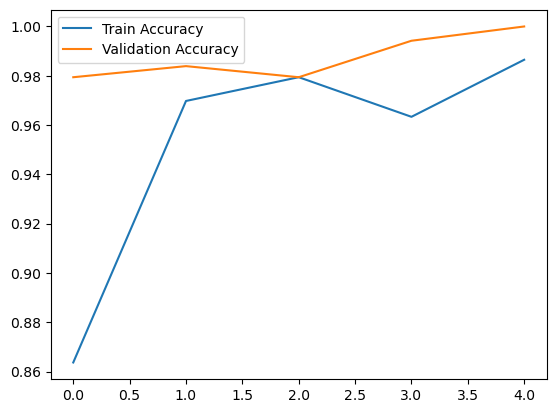

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

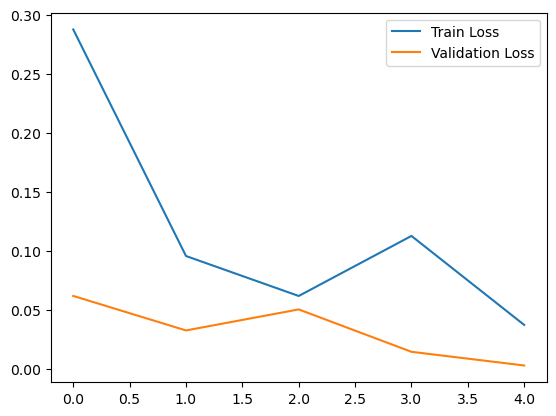

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [11]:
model.save("tooth_decay_model.keras")

In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'test', 'test.jpg', 'tooth_decay_model.keras', 'train', 'vvp.ipynb']


In [2]:
from tensorflow.keras.models import load_model

model = load_model("tooth_decay_model.keras")
print("Model Loaded Successfully")

C:\Users\POOJADANALAKSHMI\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Model Loaded Successfully


In [6]:
print(model.input_shape)

(None, 128, 128, 3)


In [33]:
def predict_image(img_path):

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    prob = prediction[0][0]

    print("Raw Probability:", prob)

    if prob < 0.3:
        print("High Risk Tooth Decay")
    elif prob < 0.6:
        print("Moderate Risk Tooth Decay")
    elif prob < 0.9:
        print("Low Risk Tooth Decay")
    else:
        print("Healthy Tooth")

In [34]:
predict_image("test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Raw Probability: 8.591368e-05
High Risk Tooth Decay


In [35]:
predict_image("test1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Raw Probability: 0.99990916
Healthy Tooth


In [39]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    ------

In [3]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis("off")
else:
    print("Camera not working")

cap.release()

Camera not working


In [5]:
import cv2
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not working")
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis('off')
    display(plt.gcf())
    clear_output(wait=True)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()

Camera not working


In [6]:
import sys
print(sys.executable)

C:\Users\POOJADANALAKSHMI\anaconda3\python.exe


In [2]:
print(model.input_shape)

(None, 128, 128, 3)


In [15]:
print(train_data.class_indices)

NameError: name 'train_data' is not defined

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

print(train_data.class_indices)

Found 1555 images belonging to 2 classes.
{'cavity': 0, 'healthy': 1}


In [19]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("tooth_decay_model.keras")

img = cv2.imread("real test.jpg")

if img is None:
    print("Image not found. Check file name again.")
else:
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    prediction = model.predict(img)
    prob = prediction[0][0]

    print("Probability:", prob)

    if prob < 0.5:
        print("Prediction: Cavity")
    else:
        print("Prediction: Healthy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Probability: 0.19423577
Prediction: Cavity


In [19]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("tooth_decay_model.keras")

img = cv2.imread("real test.jpg")

if img is None:
    print("Image not found. Check file name again.")
else:
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    prediction = model.predict(img)
    prob = prediction[0][0]

    print("Probability:", prob)

    if prob < 0.5:
        print("Prediction: Cavity")
    else:
        print("Prediction: Healthy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Probability: 0.19423577
Prediction: Cavity


In [19]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("tooth_decay_model.keras")

img = cv2.imread("real test.jpg")

if img is None:
    print("Image not found. Check file name again.")
else:
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    prediction = model.predict(img)
    prob = prediction[0][0]

    print("Probability:", prob)

    if prob < 0.5:
        print("Prediction: Cavity")
    else:
        print("Prediction: Healthy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Probability: 0.19423577
Prediction: Cavity


In [21]:
train_data = train_datagen.flow_from_directory(
    "train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 1245 images belonging to 2 classes.
Found 310 images belonging to 2 classes.


In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 447s 6s/step - accuracy: 0.9928 - loss: 0.0195 - val_accuracy: 0.9323 - val_loss: 0.2853
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 373s 5s/step - accuracy: 0.9912 - loss: 0.0242 - val_accuracy: 0.9935 - val_loss: 0.0449
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 368s 5s/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9226 - val_loss: 0.3394
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9258 - val_loss: 0.3186
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 1.0000 - loss: 4.9566e-04 - val_accuracy: 0.9452 - val_loss: 0.1496
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9968 - loss: 0.0065 - val_accuracy: 0.9323 - val_loss: 0.2383
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 1.0000 - loss: 5.8190e-04 - val_accuracy: 0.9000 - val_loss: 0.6636
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.

In [1]:
model.save("tooth_decay_model.keras")

NameError: name 'model' is not defined

In [1]:
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("tooth_decay_model.keras")

img = image.load_img("test.jpg", target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

C:\Users\POOJADANALAKSHMI\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
[[8.591368e-05]]
